In [7]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle


In [9]:
dataset_name= 'cervical'


In [3]:
 # as the name suggest this dataset was created just as a toy example
# inside privgen_generate.ipynb notebook you can find a funciton called download_dataset
# which can be used to download specific datasets from UCI database
data = pd.read_csv('../datasets/cervical-cancer_csv.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

## Imputation

In [12]:
from sklearn.impute import SimpleImputer

cols = data.columns
imp = SimpleImputer(strategy="most_frequent")
data = pd.DataFrame(imp.fit_transform(data))
data.columns = cols

## Encoding

In [ ]:
encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)


## DBSCAN HyperParameter Optimization

In [ ]:

    # GRID-SEARCH
hyper_param_opt.hyper_param_search(
    encoded_data,
    percentage_outliers=0.1,
    dataset_name=dataset_name,
    top_n=10,
    eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
    min_samples_values=range(30, 50),
    save=True)

## REMOVE DBSCAN OUTLIERS



In [22]:
outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=31,
                                                        metric='euclidean', algorithm='ball_tree',
                                                        leaf_size=50, dataset_name=dataset_name, p=1, plot=False)


Percentage of outliers removed: 39.52%
Number of clusters found: 2


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,cluster
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34.0,1.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,42.0,3.0,23.0,2.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,27.0,1.0,17.0,3.0,0.0,0.0,0.0,1.0,8.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,43.0,3.0,17.0,3.0,0.0,0.0,0.0,1.0,5.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
501,34.0,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
502,32.0,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
503,33.0,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



## GET DISTRIBUTIONS


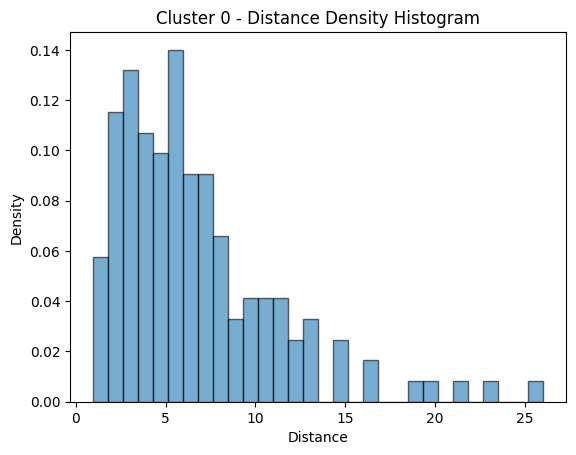

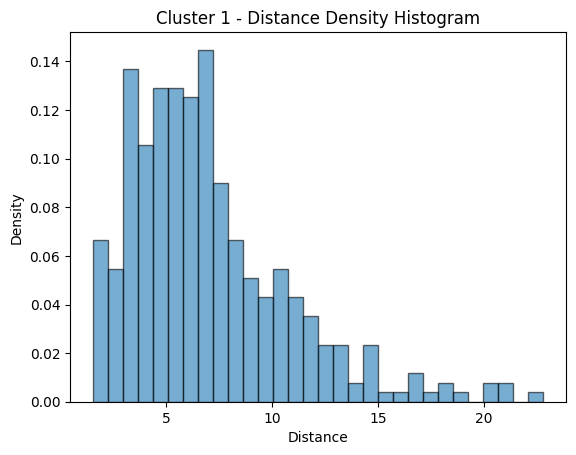

In [23]:
weighted_distance_calculation.calculate_plot_distance(dataset_name)



## REMOVE DISTANT OUTLIERS


In [24]:
threshold = {'0': 20, '1': 18}

outlier_detection_by_dist.filter_and_save_by_distance(
    dataset_name, threshold, plot=False)



## PLOT


In [ ]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.style.use('default')
# plt.style.use('ggplot')


/Users/navid/Documents/0_Research/0_venues/Privgen/utils/final_plot.py:56: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(outliers_distance['feature_0'], outliers_distance['feature_1'],


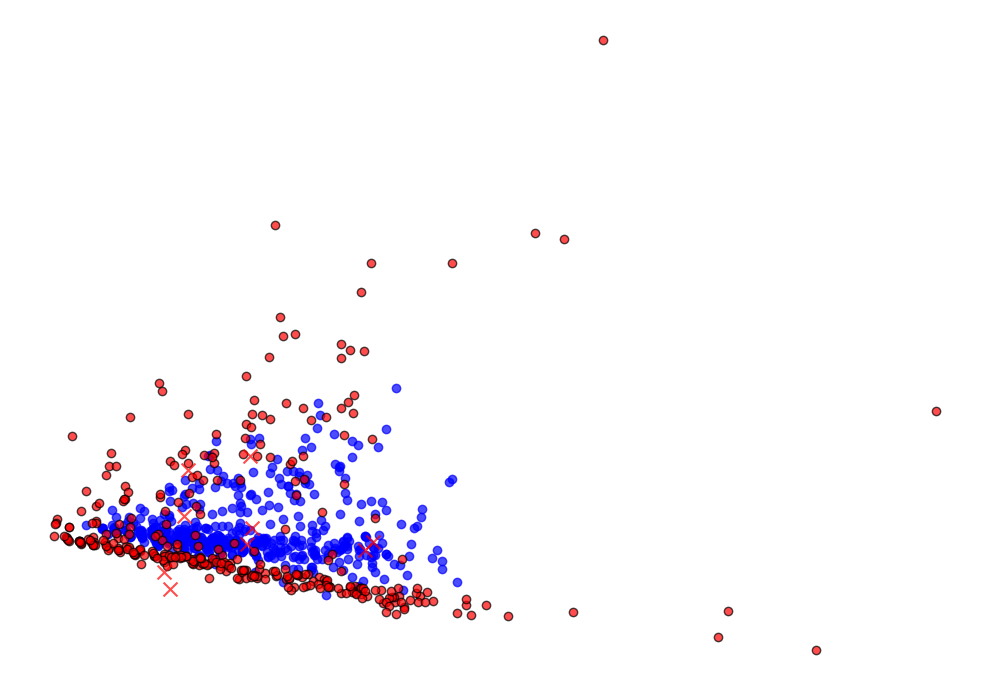

In [10]:

final_plot.plot_data_points(dataset_name, 'Cervical Cancer')



## DECODING


In [26]:
decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

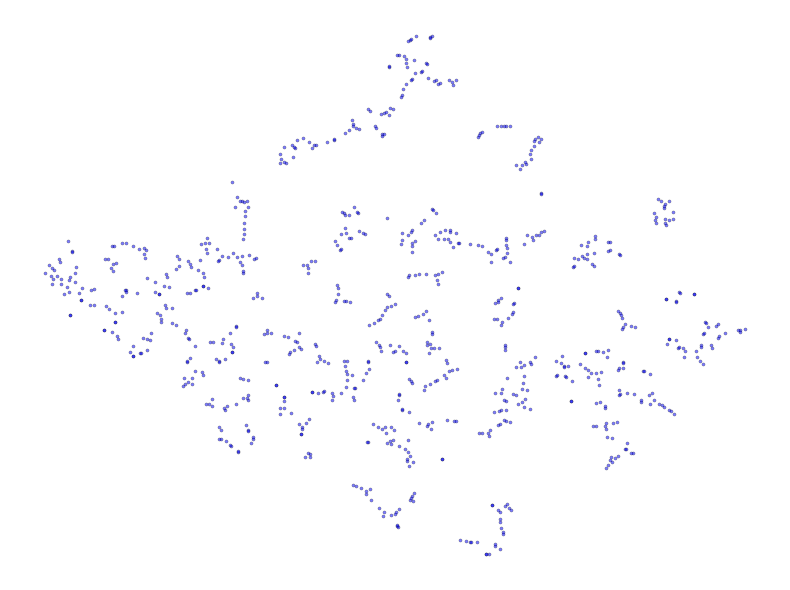

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Load the CSV file
df = data

# Encode categorical columns, including 'sex'
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    df[col] = df[col].astype(str)  # Convert to string to ensure consistency
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Prepare the data for t-SNE
X = df.drop('claim', axis=1, errors='ignore')  # Exclude target column if needed
X = X.dropna(axis=0)  # Handle missing data

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot the t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], color='blue', edgecolors='black', s=5, alpha=0.5, linewidth=0.3)

# Remove x and y ticks
plt.xticks([])
plt.yticks([])

ax = plt.gca()
# Remove borders
ax.set_frame_on(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust layout and save without extra padding
plt.tight_layout()
plt.box(True)
plt.savefig('../figures/tsne_cervical.pdf')

#plt.title('t-SNE Plot')
plt.show()